In [231]:
import yaml
import pandas as pd
import os
import numpy as np
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import importlib
sys.path.append("/work/z19/z19/lparisi/nfs-testing/workflows/lib/python")
import collect
importlib.reload(collect)

import parameters
try:
    from yaml import CLoader as Loader, CDumper as Dumper
except ImportError:
    from yaml import Loader, Dumper
sns.set_style("whitegrid")

In [232]:
benchmarks_root="/work/z19/shared/lparisi/vast_lustre_benchmarks26/runs/cylc-run/posix_single_node/runN/share"


collect.get_performance(benchmarks_root,prefix="iobenchmark_")

,repeatIndex,nodes,tasksPerNode,chunkSize,chunksPerTask,direct,filesystem,singleFile,repeat,bandwidth,dataSize
0,0,1,1,32,64,False,lustre,False,10,2.201732,2.305843
1,0,1,1,32,64,False,lustre,False,10,2.120010,2.305843
2,0,1,1,32,64,False,lustre,False,10,2.161593,2.305843
3,0,1,1,32,64,False,lustre,False,10,2.112290,2.305843
4,0,1,1,32,64,False,lustre,False,10,2.197071,2.305843
...,...,...,...,...,...,...,...,...,...,...,...
115,0,1,144,32,64,False,vast,False,10,20.131430,332.041393
116,0,1,144,32,64,False,vast,False,10,19.812209,332.041393
117,0,1,144,32,64,False,vast,False,10,20.142145,332.041393
118,0,1,144,32,64,False,vast,False,10,20.026718,332.041393


In [233]:
def get_performance_all(benchmarks_root: str, prefix: str="") -> pd.DataFrame:
    """
    Loop over all subfolders in the benchmarks root folder and get the performance results for each benchmark run.

    ::param benchmarks_root: The path of the benchmarks root folder 
    ::type benchmarks_root: str
    ::return: A pandas DataFrame with the performance results of all benchmark runs.
    ::rtype: pd.DataFrame

    """
    
    results = []
    for benchmark_folder in os.listdir(benchmarks_root):
        if benchmark_folder.startswith(prefix):
            performance = get_performance(os.path.join(benchmarks_root, benchmark_folder), prefix=prefix)
            results.append(performance)
    return pd.concat(results, ignore_index=True)

In [234]:
data=get_performance_all(benchmarks_root, prefix="iobenchmark_")
data

,repeatIndex,nodes,tasksPerNode,chunkSize,chunksPerTask,direct,filesystem,singleFile,repeat,bandwidth,dataSize
0,0,1,1,32,64,False,lustre,False,10,2.201732,2.305843
1,0,1,1,32,64,False,lustre,False,10,2.120010,2.305843
2,0,1,1,32,64,False,lustre,False,10,2.161593,2.305843
3,0,1,1,32,64,False,lustre,False,10,2.112290,2.305843
4,0,1,1,32,64,False,lustre,False,10,2.197071,2.305843
...,...,...,...,...,...,...,...,...,...,...,...
115,0,1,144,32,64,False,vast,False,10,20.131430,332.041393
116,0,1,144,32,64,False,vast,False,10,19.812209,332.041393
117,0,1,144,32,64,False,vast,False,10,20.142145,332.041393
118,0,1,144,32,64,False,vast,False,10,20.026718,332.041393


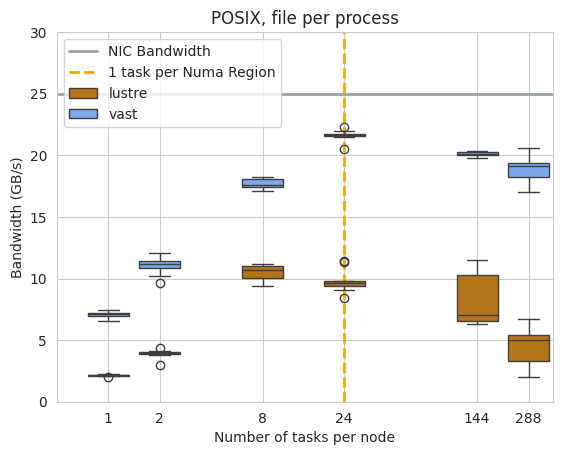

In [ ]:
import matplotlib.ticker as ticker

def single_process_plot(data: pd.DataFrame):

    #sns.pointplot(data=data.query("filesystem == 'lustre'"), x="tasksPerNode", y="bandwidth",hue="filesystem")
    fig, ax = plt.subplots()

    #for filesystem in data["filesystem"].unique():
    palette=sns.color_palette(["#FF9B19","#69A5FF","#9BA3A8","orange"])
    sns.set_palette(palette)
    ax.axhline(25, linestyle="-",label="NIC Bandwidth",color=sns.color_palette()[2],linewidth=2)
    ax.axvline(24, linestyle="--",label="1 task per Numa Region",color=sns.color_palette()[3],linewidth=2)
    sns.boxplot(data=data, x="tasksPerNode", y="bandwidth",hue="filesystem", ax=ax,
                native_scale=True,dodge=False,log_scale=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
  
    ax.set_xlim(0.5,400)
    ax.set_yscale('linear')
    ax.set_ylim(0,30)
    ax.set_xticks([1,2,8,24,144,288])
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    plt.xlabel("Number of tasks per node")
    plt.ylabel("Bandwidth (GB/s)")
    plt.title("POSIX, file per process")
    plt.legend()
single_process_plot(data)

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]